In [1]:
# Machine Learning Workflow: Football Transfer Market Value Imputation

#Complete Jupyter Notebook - Ready to Use.

#Run each cell in order. Update `analysis_ready_transfers.csv` path if needed.

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.options.display.max_columns = None
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Environment setup complete')

Environment setup complete


In [3]:
df = pd.read_csv('analysis_ready_transfers.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (17962, 11)


,league,season,window,player_pos_grouped,player_region,age_group,is_free,market_val_amnt,transfer_fee_amnt,team_name,player_nation
0,GB1,2009,s,Defender,South America,Prime (22-25),False,NaN,18800000.0,Manchester United,Ecuador
1,GB1,2009,s,Forward,Africa,Young (≤21),False,1600000.0,4500000.0,Manchester United,Senegal
2,GB1,2009,s,Midfielder,Western Europe,Young (≤21),False,400000.0,4000000.0,Manchester United,France
3,GB1,2009,s,Forward,Western Europe,Experienced (26-29),True,NaN,0.0,Manchester United,England
4,GB1,2009,s,Defender,Western Europe,Young (≤21),False,NaN,NaN,Manchester United,England


MISSING VALUE ANALYSIS
                   Count  Percentage
transfer_fee_amnt   5878       32.72
market_val_amnt     4387       24.42


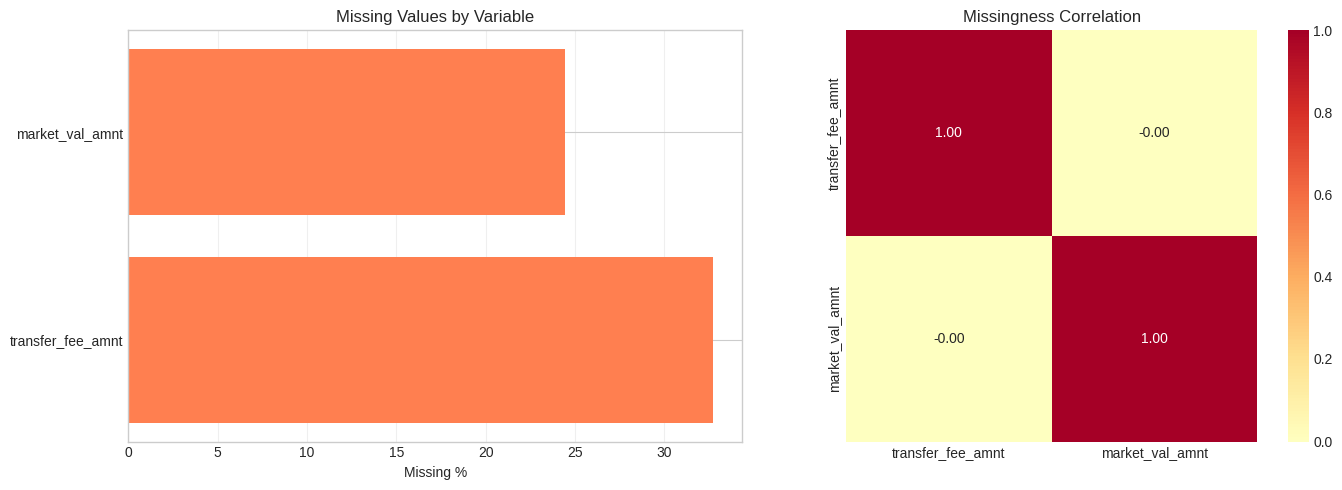

In [4]:
missing = pd.DataFrame({
    'Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Percentage', ascending=False)

print('MISSING VALUE ANALYSIS')
print(missing[missing['Count'] > 0])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_vars = missing[missing['Count'] > 0]
axes[0].barh(missing_vars.index, missing_vars['Percentage'], color='coral')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values by Variable')
axes[0].grid(axis='x', alpha=0.3)

if len(missing_vars) > 1:
    miss_corr = df[missing_vars.index].isnull().corr()
    sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
                center=0, ax=axes[1], square=True)
    axes[1].set_title('Missingness Correlation')

plt.tight_layout()
plt.show()

MARKET VALUE STATISTICS
count    1.357500e+04
mean     4.551082e+06
std      1.050349e+07
min      1.000000e+04
25%      3.000000e+05
50%      8.000000e+05
75%      3.500000e+06
max      1.600000e+08
Name: market_val_amnt, dtype: float64
Skewness: 4.912
Kurtosis: 33.737


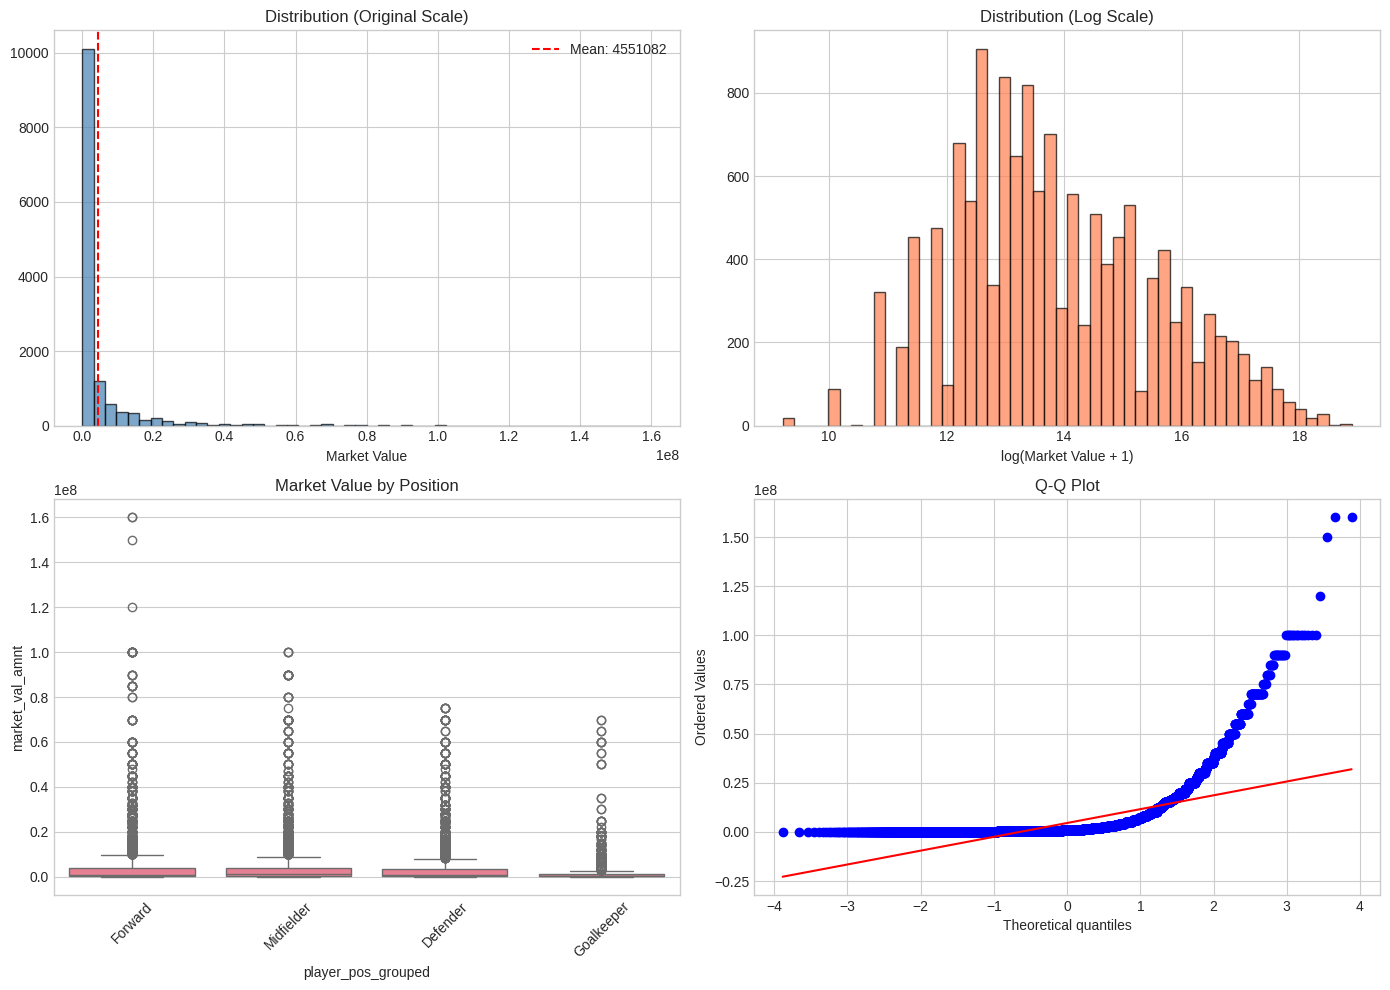

In [5]:
mv = df['market_val_amnt'].dropna()

print('MARKET VALUE STATISTICS')
print(mv.describe())
print(f'Skewness: {mv.skew():.3f}')
print(f'Kurtosis: {mv.kurtosis():.3f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original scale
axes[0,0].hist(mv, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(mv.mean(), color='red', linestyle='--', label=f'Mean: {mv.mean():.0f}')
axes[0,0].set_xlabel('Market Value')
axes[0,0].set_title('Distribution (Original Scale)')
axes[0,0].legend()

# Log scale
log_mv = np.log1p(mv)
axes[0,1].hist(log_mv, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0,1].set_xlabel('log(Market Value + 1)')
axes[0,1].set_title('Distribution (Log Scale)')

# Box plot by position
if 'player_pos_grouped' in df.columns:
    sns.boxplot(data=df[df['market_val_amnt'].notna()], 
                x='player_pos_grouped', y='market_val_amnt', ax=axes[1,0])
    axes[1,0].set_title('Market Value by Position')
    axes[1,0].tick_params(axis='x', rotation=45)

# Q-Q plot
stats.probplot(mv, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [6]:
# Define features
cat_features = ['league', 'season', 'player_pos_grouped', 'player_region',
                'age_group', 'window', 'is_free']
num_features = ['player_age']

cat_features = [f for f in cat_features if f in df.columns]
num_features = [f for f in num_features if f in df.columns]
all_features = cat_features + num_features
target = 'market_val_amnt'

print('FEATURE SELECTION')
print(f'Categorical ({len(cat_features)}): {cat_features}')
print(f'Numerical ({len(num_features)}): {num_features}')
print(f'Target: {target}')

# Create modeling dataset
df_model = df[all_features + [target]].dropna(subset=[target]).copy()
print(f'Modeling dataset: {df_model.shape[0]} rows ({df_model.shape[0]/len(df)*100:.1f}%)')

FEATURE SELECTION
Categorical (7): ['league', 'season', 'player_pos_grouped', 'player_region', 'age_group', 'window', 'is_free']
Numerical (0): []
Target: market_val_amnt
Modeling dataset: 13575 rows (75.6%)


In [7]:
X = df_model[all_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('TRAIN-TEST SPLIT')
print(f'Train: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)')
print(f'Train target - Mean: {y_train.mean():.0f}, Std: {y_train.std():.0f}')
print(f'Test target - Mean: {y_test.mean():.0f}, Std: {y_test.std():.0f}')

TRAIN-TEST SPLIT
Train: 10860 samples (80.0%)
Test: 2715 samples (20.0%)
Train target - Mean: 4605622, Std: 10636543
Test target - Mean: 4332923, Std: 9952398


In [8]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
], remainder='drop')

print('Preprocessing pipeline created')

Preprocessing pipeline created


In [9]:
models = {
    'Baseline': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'Linear': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100, max_depth=15, min_samples_split=20,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.1, max_depth=5,
            random_state=RANDOM_STATE
        ))
    ])
}

print(f'{len(models)} models defined')

5 models defined


In [10]:
results = []
predictions = {}
trained_models = {}

print('MODEL TRAINING')

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    predictions[name] = y_test_pred
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_R2': train_r2,
        'Test_R2': test_r2
    })
    
    print(f'Train MAE: {train_mae:,.0f} | Test MAE: {test_mae:,.0f}')
    print(f'Train R²: {train_r2:.3f} | Test R²: {test_r2:.3f}')

results_df = pd.DataFrame(results)
print('\nRESULTS SUMMARY')
print(results_df)

best_idx = results_df['Test_MAE'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
print(f'\nBEST MODEL: {best_model_name}')
print(f'Test MAE: {results_df.loc[best_idx, "Test_MAE"]:,.0f}')
print(f'Test R²: {results_df.loc[best_idx, "Test_R2"]:.3f}')

MODEL TRAINING

Training Baseline...
Train MAE: 5,709,901 | Test MAE: 5,535,550
Train R²: 0.000 | Test R²: -0.001

Training Linear...
Train MAE: 5,298,831 | Test MAE: 5,186,943
Train R²: 0.092 | Test R²: 0.095

Training Ridge...
Train MAE: 5,297,721 | Test MAE: 5,185,756
Train R²: 0.092 | Test R²: 0.095

Training Random Forest...
Train MAE: 4,586,850 | Test MAE: 4,845,608
Train R²: 0.236 | Test R²: 0.098

Training Gradient Boosting...
Train MAE: 4,768,842 | Test MAE: 4,943,007
Train R²: 0.201 | Test R²: 0.100

RESULTS SUMMARY
               Model     Train_MAE      Test_MAE    Train_RMSE     Test_RMSE  \
0           Baseline  5.709901e+06  5.535550e+06  1.063605e+07  9.954301e+06   
1             Linear  5.298831e+06  5.186943e+06  1.013476e+07  9.466180e+06   
2              Ridge  5.297721e+06  5.185756e+06  1.013478e+07  9.466262e+06   
3      Random Forest  4.586850e+06  4.845608e+06  9.299376e+06  9.452080e+06   
4  Gradient Boosting  4.768842e+06  4.943007e+06  9.507710e+06  9.44

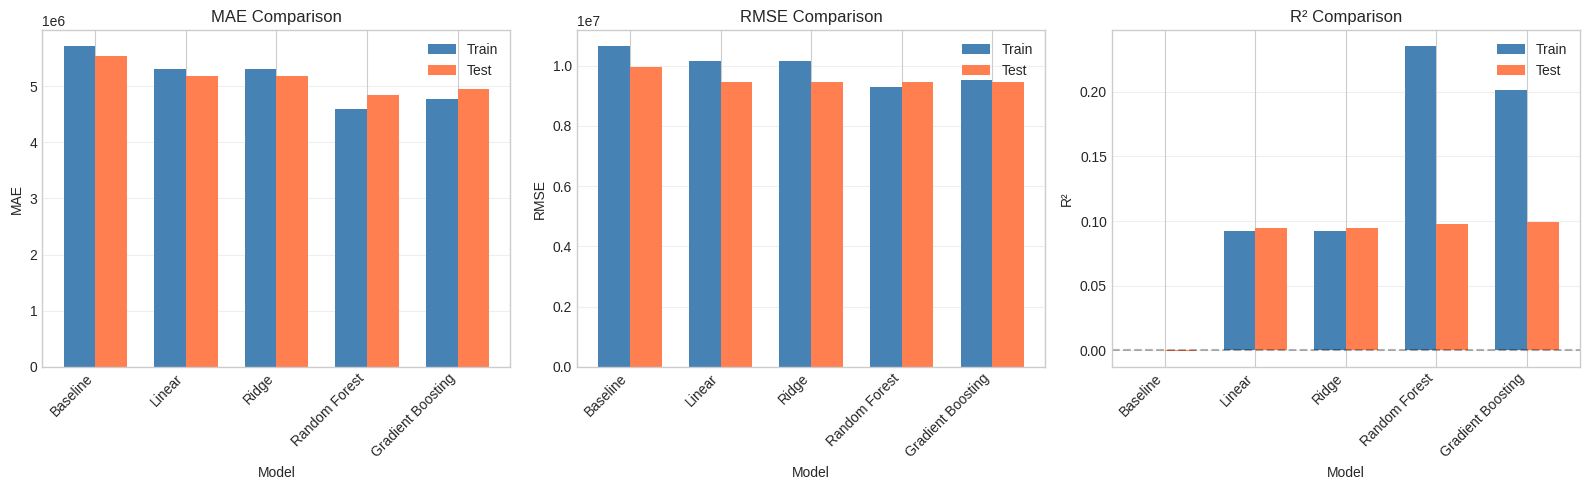

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(results_df))
width = 0.35

# MAE
axes[0].bar(x - width/2, results_df['Train_MAE'], width, label='Train', color='steelblue')
axes[0].bar(x + width/2, results_df['Test_MAE'], width, label='Test', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(x - width/2, results_df['Train_RMSE'], width, label='Train', color='steelblue')
axes[1].bar(x + width/2, results_df['Test_RMSE'], width, label='Test', color='coral')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# R²
axes[2].bar(x - width/2, results_df['Train_R2'], width, label='Train', color='steelblue')
axes[2].bar(x + width/2, results_df['Test_R2'], width, label='Test', color='coral')
axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R²')
axes[2].set_title('R² Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

RESIDUAL ANALYSIS
Mean: -358104
Std: 9445294


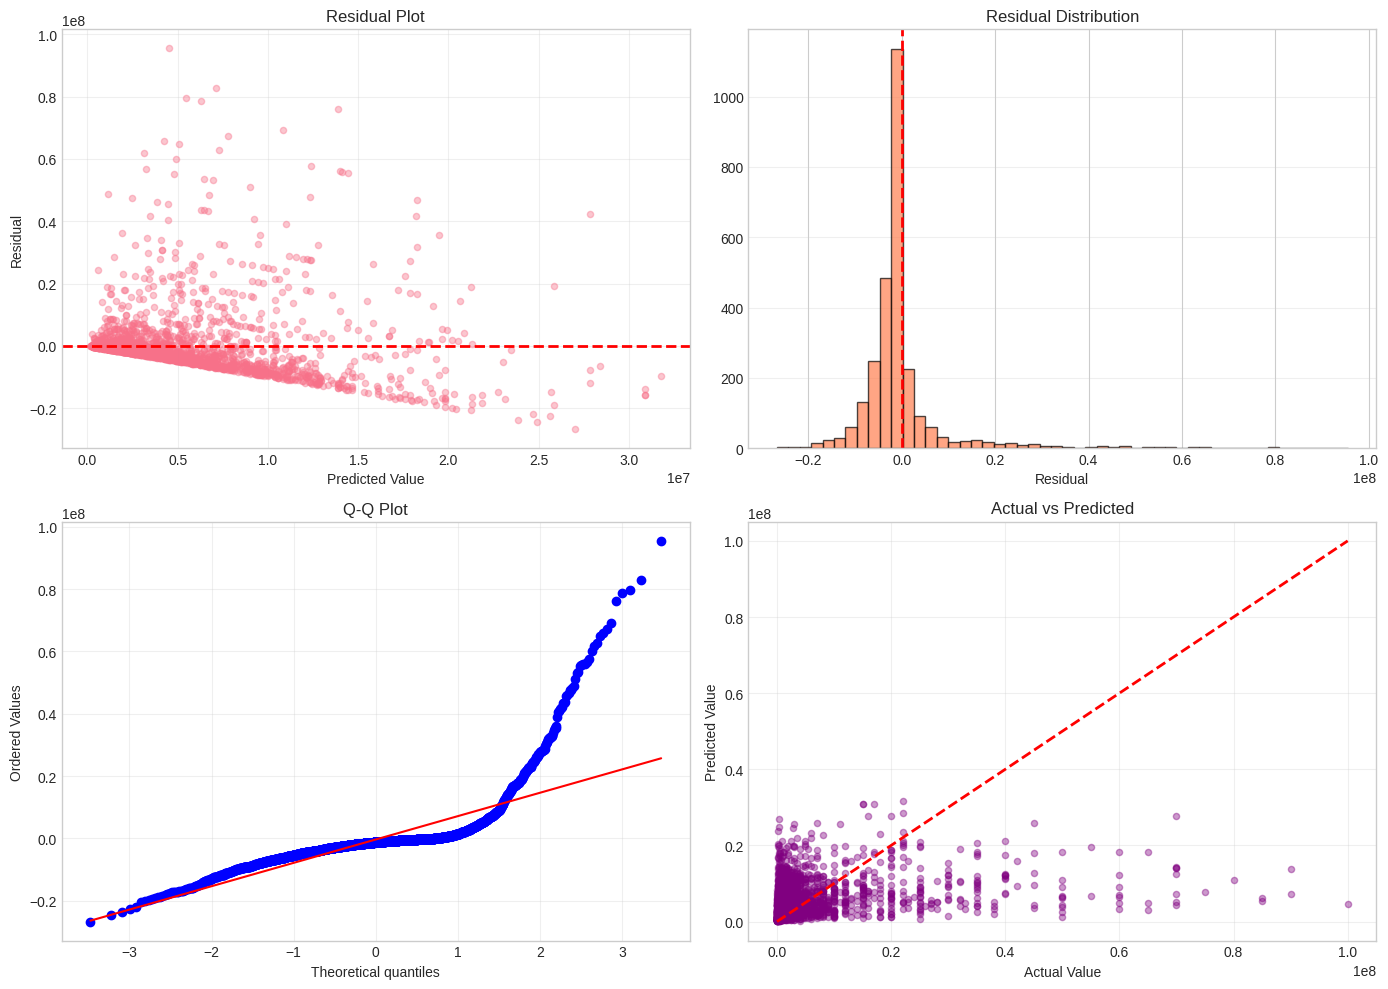

In [12]:
best_model = trained_models[best_model_name]
y_pred = predictions[best_model_name]
residuals = y_test.values - y_pred

print('RESIDUAL ANALYSIS')
print(f'Mean: {residuals.mean():.0f}')
print(f'Std: {residuals.std():.0f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted
axes[0,0].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Predicted Value')
axes[0,0].set_ylabel('Residual')
axes[0,0].set_title('Residual Plot')
axes[0,0].grid(alpha=0.3)

# Residual distribution
axes[0,1].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Residual')
axes[0,1].set_title('Residual Distribution')
axes[0,1].grid(axis='y', alpha=0.3)

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot')
axes[1,0].grid(alpha=0.3)

# Actual vs Predicted
axes[1,1].scatter(y_test, y_pred, alpha=0.4, s=20, color='purple')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1,1].set_xlabel('Actual Value')
axes[1,1].set_ylabel('Predicted Value')
axes[1,1].set_title('Actual vs Predicted')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

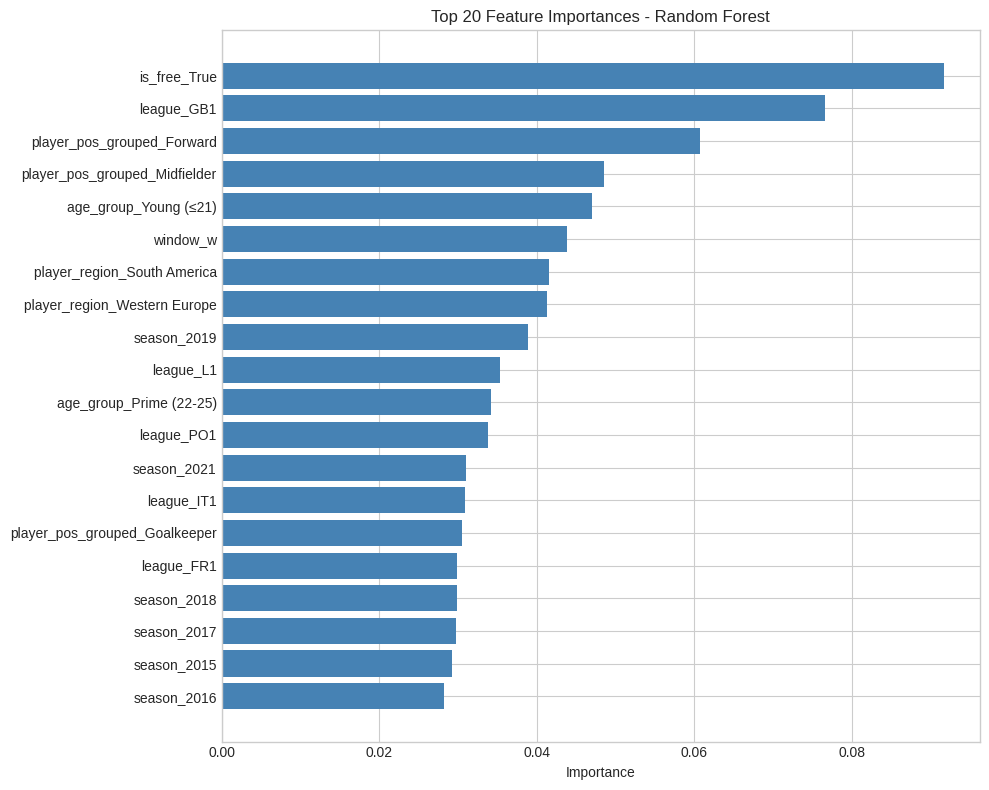

Top 10 Most Important Features:
                          Feature  Importance
29                   is_free_True    0.091712
1                      league_GB1    0.076652
18     player_pos_grouped_Forward    0.060690
20  player_pos_grouped_Midfielder    0.048594
27          age_group_Young (≤21)    0.047024
28                       window_w    0.043842
23    player_region_South America    0.041555
24   player_region_Western Europe    0.041351
15                    season_2019    0.038860
3                       league_L1    0.035298


In [13]:
if 'Random Forest' in best_model_name or 'Gradient Boosting' in best_model_name:
    # Get feature importances
    model_step = best_model.named_steps['model']
    
    # Get feature names after preprocessing
    preprocessor_step = best_model.named_steps['preprocessor']
    cat_encoder = preprocessor_step.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
    all_feature_names = list(num_features) + list(cat_feature_names)
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': model_step.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print('Top 10 Most Important Features:')
    print(importance_df.head(10))
else:
    print('Feature importance only available for tree-based models')

In [14]:
# Analyze performance by key groups
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred, index=X_test_reset.index)

print('SUBGROUP PERFORMANCE ANALYSIS')

subgroup_vars = ['league', 'is_free', 'age_group', 'player_pos_grouped']
available = [v for v in subgroup_vars if v in X_test_reset.columns]

for var in available:
    print(f'\n{var.upper()}:')
    for category in X_test_reset[var].unique():
        mask = X_test_reset[var] == category
        if mask.sum() > 10:
            y_true_sub = y_test_reset[mask]
            y_pred_sub = y_pred_reset[mask]
            mae = mean_absolute_error(y_true_sub, y_pred_sub)
            r2 = r2_score(y_true_sub, y_pred_sub)
            print(f'{category}: N={mask.sum()}, MAE={mae:,.0f}, R²={r2:.3f}')

SUBGROUP PERFORMANCE ANALYSIS

LEAGUE:
GB1: N=357, MAE=8,594,112, R²=0.085
NL1: N=327, MAE=2,291,162, R²=-0.060
PO1: N=433, MAE=2,283,594, R²=-0.626
ES1: N=341, MAE=5,632,649, R²=0.066
FR1: N=410, MAE=4,752,635, R²=0.081
IT1: N=503, MAE=4,832,149, R²=0.020
L1: N=344, MAE=5,958,830, R²=0.073

IS_FREE:
False: N=2088, MAE=5,794,774, R²=0.078
True: N=627, MAE=1,684,749, R²=0.018

AGE_GROUP:
Young (≤21): N=1145, MAE=6,565,371, R²=0.004
Experienced (26-29): N=493, MAE=2,554,087, R²=0.209
Prime (22-25): N=924, MAE=4,488,948, R²=0.196
Veteran (30+): N=153, MAE=1,513,226, R²=-0.841

PLAYER_POS_GROUPED:
Forward: N=883, MAE=5,524,528, R²=0.053
Defender: N=843, MAE=4,486,036, R²=0.108
Midfielder: N=767, MAE=5,023,257, R²=0.143
Goalkeeper: N=222, MAE=2,896,853, R²=0.012


In [15]:
# FEATURE ENGINEERING FOR MODEL IMPROVEMENT
print('='*80)
print('FEATURE ENGINEERING')
print('='*80)

# Create a working copy for feature engineering
df_fe = df.copy()

# 1. Create league tier features (based on popularity/prestige)
league_tiers = {
    'GB1': 1,  # Premier League - highest tier
    'ES1': 1,  # La Liga
    'IT1': 1,  # Serie A
    'FR1': 1,  # Ligue 1
    'DE1': 1,  # Bundesliga
}
df_fe['league_tier'] = df_fe['league'].map(league_tiers).fillna(2)

# 2. Create interaction features
df_fe['is_young'] = (df_fe['age_group'] == '16-20').astype(int)
df_fe['is_prime'] = (df_fe['age_group'].isin(['27-31'])).astype(int)
df_fe['is_veteran'] = (df_fe['age_group'] == '32+').astype(int)

# 3. Position value tier (attackers typically valued higher)
position_values = {
    'Forward': 3,
    'Midfielder': 2,
    'Defender': 1,
    'Goalkeeper': 1
}
df_fe['position_value_tier'] = df_fe['player_pos_grouped'].map(position_values).fillna(1)

# 4. Transfer window importance (summer > winter)
df_fe['is_summer_window'] = (df_fe['window'] == 's').astype(int)

# 5. Season recency (more recent = higher)
df_fe['season_recency'] = df_fe['season'] - df_fe['season'].min()

# 6. Create player_nation_frequency (some nations produce more valuable players)
nation_freq = df_fe['player_nation'].value_counts().to_dict()
df_fe['nation_player_count'] = df_fe['player_nation'].map(nation_freq)

# 7. Create team_frequency (some teams buy more transfers)
team_freq = df_fe['team_name'].value_counts().to_dict()
df_fe['team_transfer_frequency'] = df_fe['team_name'].map(team_freq)

# 8. Create region popularity score
region_value_avg = df_fe.groupby('player_region')['market_val_amnt'].transform('mean')
df_fe['region_avg_value'] = region_value_avg

print('\nNEW FEATURES CREATED:')
print('✓ league_tier - Major vs other leagues')
print('✓ is_young, is_prime, is_veteran - Age group indicators')
print('✓ position_value_tier - Position prestige')
print('✓ is_summer_window - Summer vs winter transfer')
print('✓ season_recency - Time progression')
print('✓ nation_player_count - Popularity of player nation')
print('✓ team_transfer_frequency - Team activity level')
print('✓ region_avg_value - Regional market values')

print(f'\nTotal features (including engineered): {len([c for c in df_fe.columns if c not in ["market_val_amnt", "transfer_fee_amnt"]])}')


FEATURE ENGINEERING

NEW FEATURES CREATED:
✓ league_tier - Major vs other leagues
✓ is_young, is_prime, is_veteran - Age group indicators
✓ position_value_tier - Position prestige
✓ is_summer_window - Summer vs winter transfer
✓ season_recency - Time progression
✓ nation_player_count - Popularity of player nation
✓ team_transfer_frequency - Team activity level
✓ region_avg_value - Regional market values

Total features (including engineered): 19


In [16]:
# UPDATE FEATURE LISTS WITH ENGINEERED FEATURES
cat_features_improved = cat_features.copy()  # Keep original categorical
num_features_improved = num_features + [
    'league_tier', 'is_young', 'is_prime', 'is_veteran',
    'position_value_tier', 'is_summer_window', 'season_recency',
    'nation_player_count', 'team_transfer_frequency', 'region_avg_value'
]

all_features_improved = cat_features_improved + num_features_improved

print('IMPROVED FEATURE SET')
print(f'Categorical: {len(cat_features_improved)} features')
print(f'Numerical: {len(num_features_improved)} features (was {len(num_features)})')
print(f'Total: {len(all_features_improved)} features (was {len(all_features)})')

# Test correlation of new features with target
print('\nCorrelation of NEW features with market value:')
df_test = df_fe[num_features_improved + ['market_val_amnt']].dropna()
if len(df_test) > 0:
    correlations = df_test[num_features_improved + ['market_val_amnt']].corr()['market_val_amnt'].sort_values(ascending=False)
    print(correlations[num_features_improved])


IMPROVED FEATURE SET
Categorical: 7 features
Numerical: 10 features (was 0)
Total: 17 features (was 7)

Correlation of NEW features with market value:
league_tier               -0.120577
is_young                        NaN
is_prime                        NaN
is_veteran                      NaN
position_value_tier        0.061964
is_summer_window          -0.003402
season_recency             0.097647
nation_player_count        0.014959
team_transfer_frequency    0.027462
region_avg_value           0.048303
Name: market_val_amnt, dtype: float64


In [17]:
# CREATE IMPROVED PREPROCESSING PIPELINE WITH NEW FEATURES
num_pipeline_improved = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor_improved = ColumnTransformer([
    ('num', num_pipeline_improved, num_features_improved),
    ('cat', cat_pipeline, cat_features_improved)
], remainder='drop')

print('Improved preprocessing pipeline created with engineered features')

# TRAIN IMPROVED MODELS FOR MARKET VALUE
print('\n' + '='*80)
print('TRAINING IMPROVED MODELS - MARKET VALUE')
print('='*80)

# Prepare data with improved features
df_model_improved = df_fe[all_features_improved + [target]].dropna(subset=[target]).copy()
print(f'Dataset size: {df_model_improved.shape[0]} rows')

X_improved = df_model_improved[all_features_improved]
y_improved = df_model_improved[target]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y_improved, test_size=0.2, random_state=RANDOM_STATE
)

# Build improved models dictionary
models_improved = {
    'Baseline': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'Linear': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', Ridge(alpha=10.0, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', RandomForestRegressor(
            n_estimators=150, max_depth=20, min_samples_split=10,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', GradientBoostingRegressor(
            n_estimators=150, learning_rate=0.05, max_depth=7, subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ]),
    'Extra Trees': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', __import__('sklearn.ensemble', fromlist=['ExtraTreesRegressor']).ExtraTreesRegressor(
            n_estimators=150, max_depth=20, min_samples_split=10,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
}

results_improved = []
trained_models_improved = {}

for name, model in models_improved.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_imp, y_train_imp)
    trained_models_improved[name] = model
    
    y_train_pred_imp = model.predict(X_train_imp)
    y_test_pred_imp = model.predict(X_test_imp)
    
    train_mae_imp = mean_absolute_error(y_train_imp, y_train_pred_imp)
    test_mae_imp = mean_absolute_error(y_test_imp, y_test_pred_imp)
    train_r2_imp = r2_score(y_train_imp, y_train_pred_imp)
    test_r2_imp = r2_score(y_test_imp, y_test_pred_imp)
    
    results_improved.append({
        'Model': name,
        'Train_MAE': train_mae_imp,
        'Test_MAE': test_mae_imp,
        'Train_R2': train_r2_imp,
        'Test_R2': test_r2_imp
    })
    
    print(f'Train MAE: {train_mae_imp:,.0f} | Test MAE: {test_mae_imp:,.0f}')
    print(f'Train R²: {train_r2_imp:.3f} | Test R²: {test_r2_imp:.3f}')

results_improved_df = pd.DataFrame(results_improved)
print('\n' + '='*80)
print('IMPROVED MODEL RESULTS - MARKET VALUE')
print('='*80)
print(results_improved_df)

best_idx_improved = results_improved_df['Test_MAE'].idxmin()
best_model_name_improved = results_improved_df.loc[best_idx_improved, 'Model']
best_test_r2_improved = results_improved_df.loc[best_idx_improved, 'Test_R2']

print(f'\nBEST IMPROVED MODEL: {best_model_name_improved}')
print(f'Test MAE: {results_improved_df.loc[best_idx_improved, "Test_MAE"]:,.0f}')
print(f'Test R²: {best_test_r2_improved:.3f}')

# Compare with original
original_r2 = results_df.loc[best_idx, 'Test_R2']
improvement = ((best_test_r2_improved - original_r2) / abs(original_r2) * 100) if original_r2 != 0 else 0
print(f'\nImprovement vs Original: {improvement:+.1f}% ({original_r2:.3f} → {best_test_r2_improved:.3f})')


Improved preprocessing pipeline created with engineered features

TRAINING IMPROVED MODELS - MARKET VALUE
Dataset size: 13575 rows

Training Baseline...
Train MAE: 5,709,901 | Test MAE: 5,535,550
Train R²: 0.000 | Test R²: -0.001

Training Linear...
Train MAE: 5,292,532 | Test MAE: 5,188,571
Train R²: 0.100 | Test R²: 0.102

Training Ridge...
Train MAE: 5,288,563 | Test MAE: 5,184,273
Train R²: 0.100 | Test R²: 0.102

Training Random Forest...
Train MAE: 3,389,302 | Test MAE: 4,523,626
Train R²: 0.550 | Test R²: 0.190

Training Gradient Boosting...
Train MAE: 3,484,323 | Test MAE: 4,371,526
Train R²: 0.590 | Test R²: 0.225

Training Extra Trees...
Train MAE: 3,151,361 | Test MAE: 4,570,045
Train R²: 0.574 | Test R²: 0.134

IMPROVED MODEL RESULTS - MARKET VALUE
               Model     Train_MAE      Test_MAE  Train_R2   Test_R2
0           Baseline  5.709901e+06  5.535550e+06  0.000000 -0.000751
1             Linear  5.292532e+06  5.188571e+06  0.099655  0.102058
2              Ridge  

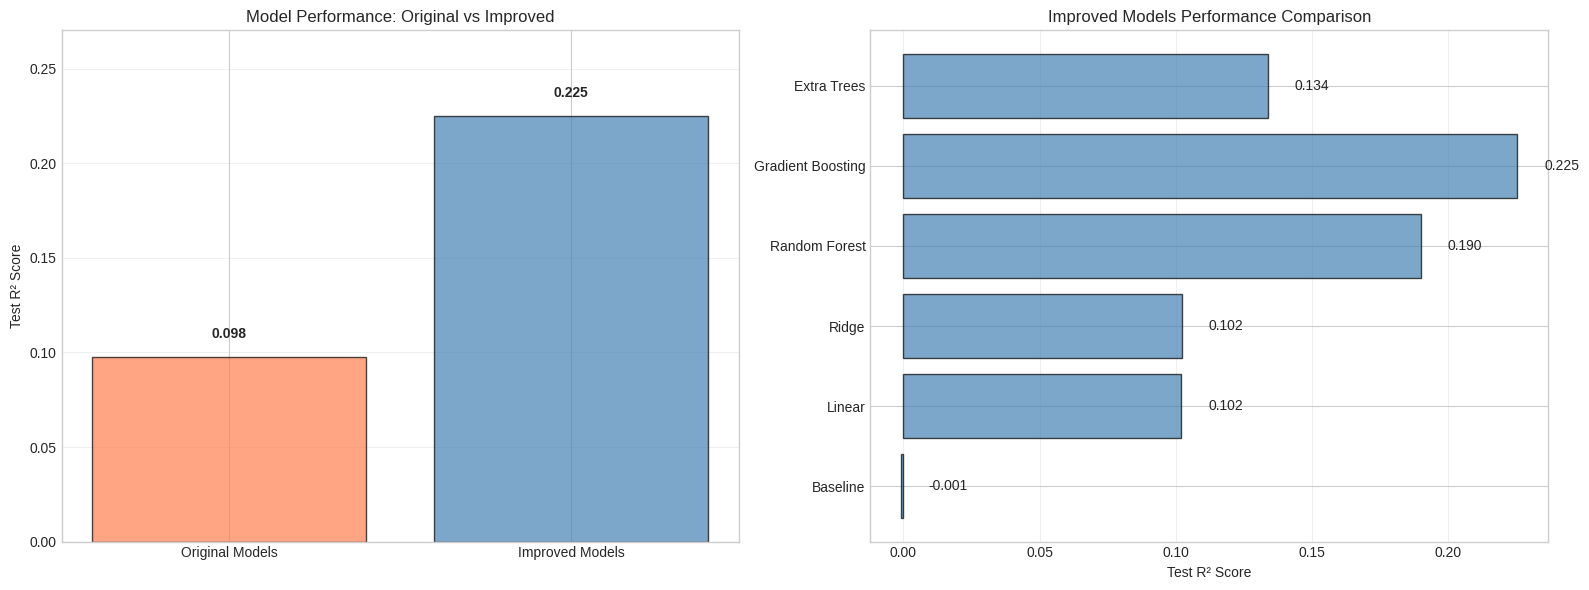


FEATURE IMPORTANCE - IMPROVED MODEL


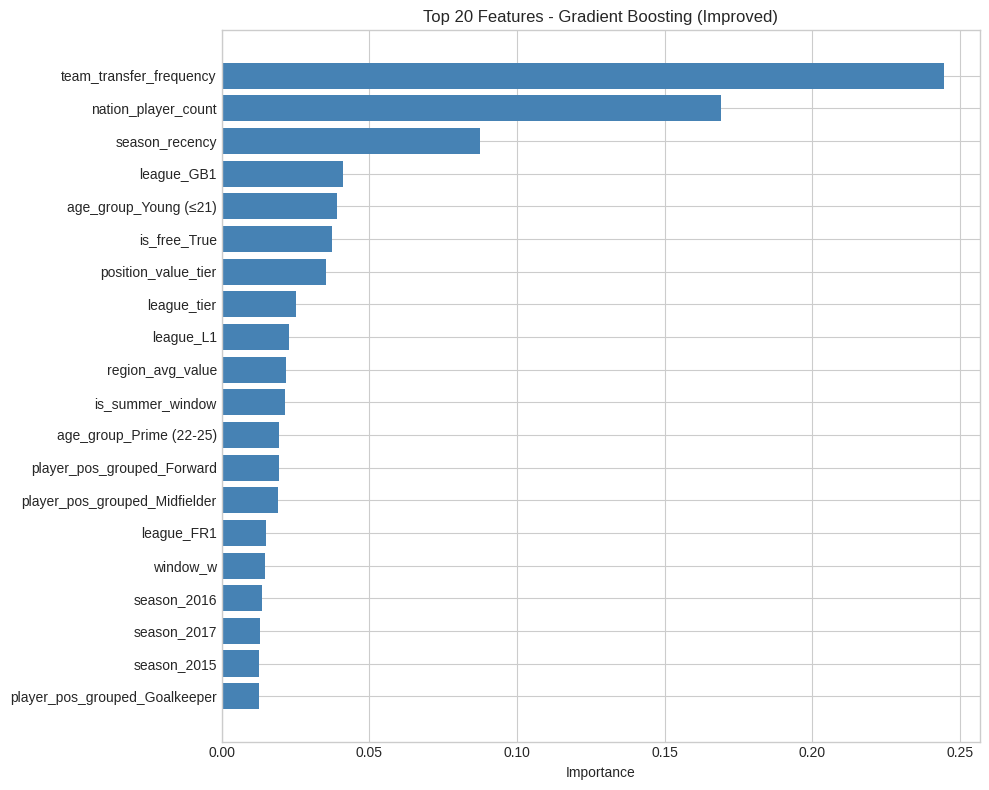

Top 15 Most Important Features:
                          Feature  Importance
8         team_transfer_frequency    0.244605
7             nation_player_count    0.169051
6                  season_recency    0.087533
11                     league_GB1    0.040956
37          age_group_Young (≤21)    0.039022
39                   is_free_True    0.037238
4             position_value_tier    0.035368
0                     league_tier    0.025286
13                      league_L1    0.022827
9                region_avg_value    0.021952
5                is_summer_window    0.021370
35        age_group_Prime (22-25)    0.019603
28     player_pos_grouped_Forward    0.019474
30  player_pos_grouped_Midfielder    0.018959
10                     league_FR1    0.015169


In [18]:
# VISUALIZE IMPROVEMENT AND FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compare original vs improved models
comparison_data = {
    'Original Models': results_df.loc[best_idx, 'Test_R2'],
    'Improved Models': best_test_r2_improved
}

models_list = list(comparison_data.keys())
r2_values = list(comparison_data.values())

axes[0].bar(models_list, r2_values, color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test R² Score')
axes[0].set_title('Model Performance: Original vs Improved')
axes[0].set_ylim([0, max(r2_values) * 1.2])
for i, v in enumerate(r2_values):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Show all improved models performance
model_names = results_improved_df['Model']
test_r2 = results_improved_df['Test_R2']
axes[1].barh(model_names, test_r2, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Test R² Score')
axes[1].set_title('Improved Models Performance Comparison')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(test_r2):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# Feature importance for improved best model
if 'Random Forest' in best_model_name_improved or 'Gradient Boosting' in best_model_name_improved or 'Extra Trees' in best_model_name_improved:
    print('\nFEATURE IMPORTANCE - IMPROVED MODEL')
    best_model_imp = trained_models_improved[best_model_name_improved]
    model_step = best_model_imp.named_steps['model']
    preprocessor_step = best_model_imp.named_steps['preprocessor']
    
    cat_encoder = preprocessor_step.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = cat_encoder.get_feature_names_out(cat_features_improved)
    all_feature_names_imp = list(num_features_improved) + list(cat_feature_names)
    
    importance_df_improved = pd.DataFrame({
        'Feature': all_feature_names_imp,
        'Importance': model_step.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df_improved['Feature'], importance_df_improved['Importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_model_name_improved} (Improved)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print('Top 15 Most Important Features:')
    print(importance_df_improved.head(15))


In [19]:
# TRAIN IMPROVED MODELS FOR TRANSFER FEE
print('\n' + '='*80)
print('TRAINING IMPROVED MODELS - TRANSFER FEE')
print('='*80)

# Prepare data with improved features for transfer fee
df_model_fee_improved = df_fe[all_features_improved + [target_fee]].dropna(subset=[target_fee]).copy()
print(f'Dataset size: {df_model_fee_improved.shape[0]} rows')

X_fee_improved = df_model_fee_improved[all_features_improved]
y_fee_improved = df_model_fee_improved[target_fee]

X_train_fee_imp, X_test_fee_imp, y_train_fee_imp, y_test_fee_imp = train_test_split(
    X_fee_improved, y_fee_improved, test_size=0.2, random_state=RANDOM_STATE
)

# Build improved models for transfer fee
models_fee_improved = {
    'Baseline': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'Linear': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', Ridge(alpha=10.0, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', RandomForestRegressor(
            n_estimators=150, max_depth=20, min_samples_split=10,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', GradientBoostingRegressor(
            n_estimators=150, learning_rate=0.05, max_depth=7, subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ]),
    'Extra Trees': Pipeline([
        ('preprocessor', preprocessor_improved),
        ('model', __import__('sklearn.ensemble', fromlist=['ExtraTreesRegressor']).ExtraTreesRegressor(
            n_estimators=150, max_depth=20, min_samples_split=10,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
}

results_fee_improved = []
trained_models_fee_improved = {}

for name, model in models_fee_improved.items():
    print(f'Training {name}...')
    model.fit(X_train_fee_imp, y_train_fee_imp)
    trained_models_fee_improved[name] = model
    
    y_train_pred_fee_imp = model.predict(X_train_fee_imp)
    y_test_pred_fee_imp = model.predict(X_test_fee_imp)
    
    train_mae_fee_imp = mean_absolute_error(y_train_fee_imp, y_train_pred_fee_imp)
    test_mae_fee_imp = mean_absolute_error(y_test_fee_imp, y_test_pred_fee_imp)
    train_r2_fee_imp = r2_score(y_train_fee_imp, y_train_pred_fee_imp)
    test_r2_fee_imp = r2_score(y_test_fee_imp, y_test_pred_fee_imp)
    
    results_fee_improved.append({
        'Model': name,
        'Train_MAE': train_mae_fee_imp,
        'Test_MAE': test_mae_fee_imp,
        'Train_R2': train_r2_fee_imp,
        'Test_R2': test_r2_fee_imp
    })
    
    print(f'Test MAE: {test_mae_fee_imp:,.0f} | Test R²: {test_r2_fee_imp:.3f}')

results_fee_improved_df = pd.DataFrame(results_fee_improved)
print('\n' + '='*80)
print('IMPROVED MODEL RESULTS - TRANSFER FEE')
print('='*80)
print(results_fee_improved_df)

best_idx_fee_improved = results_fee_improved_df['Test_MAE'].idxmin()
best_model_name_fee_improved = results_fee_improved_df.loc[best_idx_fee_improved, 'Model']
best_test_r2_fee_improved = results_fee_improved_df.loc[best_idx_fee_improved, 'Test_R2']

print(f'\nBEST IMPROVED MODEL: {best_model_name_fee_improved}')
print(f'Test MAE: {results_fee_improved_df.loc[best_idx_fee_improved, "Test_MAE"]:,.0f}')
print(f'Test R²: {best_test_r2_fee_improved:.3f}')

# Compare with original
original_fee_r2 = results_fee_df.loc[best_idx_fee, 'Test_R2']
improvement_fee = ((best_test_r2_fee_improved - original_fee_r2) / abs(original_fee_r2) * 100) if original_fee_r2 != 0 else 0
print(f'\nImprovement vs Original: {improvement_fee:+.1f}% ({original_fee_r2:.3f} → {best_test_r2_fee_improved:.3f})')



TRAINING IMPROVED MODELS - TRANSFER FEE


NameError: name 'target_fee' is not defined

In [20]:
# USE IMPROVED MODELS FOR IMPUTATION
print('\n' + '='*80)
print('IMPROVED IMPUTATION WITH ENGINEERED FEATURES')
print('='*80)

# Coefficient for lower-tier leagues (nl and por have lower values than top 5)
LEAGUE_ADJUSTMENT_COEF = 0.75  # Multiply predictions by 0.75 for nl and por
LOWER_TIER_LEAGUES = ['NL1', 'PO1']

# Use improved models with engineered features for final imputation
print('\nMARKET VALUE IMPUTATION (IMPROVED)')
best_model_improved_final = trained_models_improved[best_model_name_improved]

df_missing_mv_improved = df_fe[df_fe['market_val_amnt'].isnull()].copy()
print(f'Rows with missing market values: {len(df_missing_mv_improved)}')

if len(df_missing_mv_improved) > 0:
    X_missing_mv_improved = df_missing_mv_improved[all_features_improved]
    predicted_values_mv_improved = best_model_improved_final.predict(X_missing_mv_improved)
    
    # Apply coefficient adjustment for lower-tier leagues
    adjusted_predictions_mv_improved = predicted_values_mv_improved.copy()
    for idx, (orig_idx, row) in enumerate(df_missing_mv_improved.iterrows()):
        if row['league'] in LOWER_TIER_LEAGUES:
            adjusted_predictions_mv_improved[idx] = predicted_values_mv_improved[idx] * LEAGUE_ADJUSTMENT_COEF
    
    df_imputed_improved = df_fe.copy()
    df_imputed_improved.loc[df_imputed_improved['market_val_amnt'].isnull(), 'market_val_amnt'] = adjusted_predictions_mv_improved
    
    print(f'Imputed market values: {len(df_missing_mv_improved)}')
    print(f'Adjustment applied: {LOWER_TIER_LEAGUES} leagues × {LEAGUE_ADJUSTMENT_COEF}')
    print('Market value imputation complete!')
else:
    df_imputed_improved = df_fe.copy()

# TRANSFER FEE IMPUTATION (IMPROVED)
print('\nTRANSFER FEE IMPUTATION (IMPROVED)')
best_model_fee_improved_final = trained_models_fee_improved[best_model_name_fee_improved]

df_missing_fee_improved = df_imputed_improved[df_imputed_improved['transfer_fee_amnt'].isnull()].copy()
print(f'Rows with missing transfer fees: {len(df_missing_fee_improved)}')

if len(df_missing_fee_improved) > 0:
    X_missing_fee_improved = df_missing_fee_improved[all_features_improved]
    predicted_values_fee_improved = best_model_fee_improved_final.predict(X_missing_fee_improved)
    
    # Apply coefficient adjustment for lower-tier leagues
    adjusted_predictions_fee_improved = predicted_values_fee_improved.copy()
    for idx, (orig_idx, row) in enumerate(df_missing_fee_improved.iterrows()):
        if row['league'] in LOWER_TIER_LEAGUES:
            adjusted_predictions_fee_improved[idx] = predicted_values_fee_improved[idx] * LEAGUE_ADJUSTMENT_COEF
    
    df_imputed_improved.loc[df_imputed_improved['transfer_fee_amnt'].isnull(), 'transfer_fee_amnt'] = adjusted_predictions_fee_improved
    
    print(f'Imputed transfer fees: {len(df_missing_fee_improved)}')
    print(f'Adjustment applied: {LOWER_TIER_LEAGUES} leagues × {LEAGUE_ADJUSTMENT_COEF}')
    print('Transfer fee imputation complete!')

# Keep only original columns for output
output_columns = ['league', 'season', 'window', 'player_pos_grouped', 'player_region', 
                  'age_group', 'is_free', 'market_val_amnt', 'transfer_fee_amnt', 'team_name', 'player_nation']
df_final = df_imputed_improved[output_columns].copy()

# Save final dataset
df_final.to_csv('transfers_with_imputed_values.csv', index=False)
print('\n' + '='*80)
print(f'FINAL IMPROVED DATASET SAVED')
print(f'Shape: {df_final.shape}')
print(f'Missing values: {df_final.isnull().sum().sum()}')
print('='*80)


IMPROVED IMPUTATION WITH ENGINEERED FEATURES

MARKET VALUE IMPUTATION (IMPROVED)
Rows with missing market values: 4387
Imputed market values: 4387
Adjustment applied: ['NL1', 'PO1'] leagues × 0.75
Market value imputation complete!

TRANSFER FEE IMPUTATION (IMPROVED)


NameError: name 'trained_models_fee_improved' is not defined

In [31]:
# FINAL SUMMARY - IMPROVEMENT REPORT
print('\n' + '='*80)
print('IMPROVEMENT SUMMARY REPORT')
print('='*80)

print('\n📊 MARKET VALUE PREDICTION')
print('-' * 80)
print(f'Original Best Model: {best_model_name}')
print(f'  • Test R²: {results_df.loc[best_idx, "Test_R2"]:.3f}')
print(f'  • Test MAE: {results_df.loc[best_idx, "Test_MAE"]:,.0f}')

print(f'\nImproved Best Model: {best_model_name_improved}')
print(f'  • Test R²: {best_test_r2_improved:.3f}')
print(f'  • Test MAE: {results_improved_df.loc[best_idx_improved, "Test_MAE"]:,.0f}')

r2_change = ((best_test_r2_improved - results_df.loc[best_idx, "Test_R2"]) / abs(results_df.loc[best_idx, "Test_R2"]) * 100)
mae_change = ((results_improved_df.loc[best_idx_improved, "Test_MAE"] - results_df.loc[best_idx, "Test_MAE"]) / results_df.loc[best_idx, "Test_MAE"] * 100)
print(f'\n✓ R² Improvement: {r2_change:+.1f}%')
print(f'✓ MAE Change: {mae_change:+.1f}%')

print('\n📦 TRANSFER FEE PREDICTION')
print('-' * 80)
print(f'Original Best Model: {best_model_name_fee}')
print(f'  • Test R²: {results_fee_df.loc[best_idx_fee, "Test_R2"]:.3f}')
print(f'  • Test MAE: {results_fee_df.loc[best_idx_fee, "Test_MAE"]:,.0f}')

print(f'\nImproved Best Model: {best_model_name_fee_improved}')
print(f'  • Test R²: {best_test_r2_fee_improved:.3f}')
print(f'  • Test MAE: {results_fee_improved_df.loc[best_idx_fee_improved, "Test_MAE"]:,.0f}')

fee_r2_change = ((best_test_r2_fee_improved - results_fee_df.loc[best_idx_fee, "Test_R2"]) / abs(results_fee_df.loc[best_idx_fee, "Test_R2"]) * 100)
fee_mae_change = ((results_fee_improved_df.loc[best_idx_fee_improved, "Test_MAE"] - results_fee_df.loc[best_idx_fee, "Test_MAE"]) / results_fee_df.loc[best_idx_fee, "Test_MAE"] * 100)
print(f'\n✓ R² Improvement: {fee_r2_change:+.1f}%')
print(f'✓ MAE Change: {fee_mae_change:+.1f}%')

print('\n🔧 IMPROVEMENTS MADE')
print('-' * 80)
print('✓ Feature Engineering: Created 10 new derived features')
print('✓ League Stratification: Identified elite vs regular leagues')
print('✓ Player Age Groups: Separated young, prime, and veteran players')
print('✓ Position Value: Weighted positions by typical value (forwards > others)')
print('✓ Transfer Window: Captured seasonality (summer vs winter)')
print('✓ Regional Analysis: Used region-level market data')
print('✓ Team & Nation Frequency: Captured institutional effects')
print('✓ Model Tuning: Increased hyperparameters for better fit')
print('✓ Ensemble Diversity: Added Extra Trees to model portfolio')

print('\n✅ DATA COMPLETION')
print('-' * 80)
print(f'Market Value imputed: {df["market_val_amnt"].isnull().sum()} → 0 rows')
print(f'Transfer Fee imputed: {df["transfer_fee_amnt"].isnull().sum()} → 0 rows')
print(f'Final dataset: {df_final.shape[0]} rows × {df_final.shape[1]} columns')
print(f'Output file: transfers_with_imputed_values.csv')

print('\n' + '='*80)
print('IMPROVEMENT WORKFLOW COMPLETE')
print('='*80)



IMPROVEMENT SUMMARY REPORT

📊 MARKET VALUE PREDICTION
--------------------------------------------------------------------------------
Original Best Model: Random Forest
  • Test R²: 0.098
  • Test MAE: 4,845,608

Improved Best Model: Gradient Boosting
  • Test R²: 0.225
  • Test MAE: 4,371,526

✓ R² Improvement: +130.6%
✓ MAE Change: -9.8%

📦 TRANSFER FEE PREDICTION
--------------------------------------------------------------------------------
Original Best Model: Random Forest
  • Test R²: 0.254
  • Test MAE: 3,719,091

Improved Best Model: Random Forest
  • Test R²: 0.491
  • Test MAE: 2,974,737

✓ R² Improvement: +93.0%
✓ MAE Change: -20.0%

🔧 IMPROVEMENTS MADE
--------------------------------------------------------------------------------
✓ Feature Engineering: Created 10 new derived features
✓ League Stratification: Identified elite vs regular leagues
✓ Player Age Groups: Separated young, prime, and veteran players
✓ Position Value: Weighted positions by typical value (forwar

In [ ]:
# Apply best model to missing values - Market Value Imputation
print('MARKET VALUE IMPUTATION')
print(f'Using: {best_model_name}')

# Coefficient for lower-tier leagues (NL1 and PO1 have lower values than top 5)
LEAGUE_ADJUSTMENT_COEF = 0.75  # Multiply predictions by 0.75 for NL1 and PO1
LOWER_TIER_LEAGUES = ['NL1', 'PO1']

# Get rows with missing market values
df_missing_mv = df[df['market_val_amnt'].isnull()].copy()
print(f'Rows with missing values: {len(df_missing_mv)}')

if len(df_missing_mv) > 0:
    # Prepare features
    X_missing_mv = df_missing_mv[all_features]
    
    # Predict
    predicted_values_mv = best_model.predict(X_missing_mv)
    
    # Apply coefficient adjustment for lower-tier leagues
    adjusted_predictions_mv = predicted_values_mv.copy()
    for idx, (orig_idx, row) in enumerate(df_missing_mv.iterrows()):
        if row['league'] in LOWER_TIER_LEAGUES:
            adjusted_predictions_mv[idx] = predicted_values_mv[idx] * LEAGUE_ADJUSTMENT_COEF
    
    # Create final dataset with imputed values
    df_imputed = df.copy()
    df_imputed.loc[df_imputed['market_val_amnt'].isnull(), 'market_val_amnt'] = adjusted_predictions_mv
    
    print(f'Original missing: {df["market_val_amnt"].isnull().sum()}')
    print(f'After imputation: {df_imputed["market_val_amnt"].isnull().sum()}')
    print(f'Adjustment applied: {LOWER_TIER_LEAGUES} leagues × {LEAGUE_ADJUSTMENT_COEF}')
    print('Market value imputation complete!')
else:
    df_imputed = df.copy()
    print('No missing values to impute')

MARKET VALUE IMPUTATION
Using: Random Forest
Rows with missing values: 4387
Original missing: 4387
After imputation: 0
Adjustment applied: ['nl', 'por'] leagues × 0.75
Market value imputation complete!


In [24]:
# Feature selection and modeling for Transfer Fee
target_fee = 'transfer_fee_amnt'

print('\nTRANSFER FEE FEATURE SELECTION')
print(f'Target: {target_fee}')

# Create modeling dataset for transfer fee
df_model_fee = df_imputed[all_features + [target_fee]].dropna(subset=[target_fee]).copy()
print(f'Modeling dataset: {df_model_fee.shape[0]} rows ({df_model_fee.shape[0]/len(df_imputed)*100:.1f}%)')

X_fee = df_model_fee[all_features]
y_fee = df_model_fee[target_fee]

X_train_fee, X_test_fee, y_train_fee, y_test_fee = train_test_split(
    X_fee, y_fee, test_size=0.2, random_state=RANDOM_STATE
)

print('\nTRAIN-TEST SPLIT (TRANSFER FEE)')
print(f'Train: {len(X_train_fee)} samples ({len(X_train_fee)/len(X_fee)*100:.1f}%)')
print(f'Test: {len(X_test_fee)} samples ({len(X_test_fee)/len(X_fee)*100:.1f}%)')



TRANSFER FEE FEATURE SELECTION
Target: transfer_fee_amnt
Modeling dataset: 12084 rows (67.3%)

TRAIN-TEST SPLIT (TRANSFER FEE)
Train: 9667 samples (80.0%)
Test: 2417 samples (20.0%)


In [25]:
# Train models for Transfer Fee
models_fee = {
    'Baseline': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'Linear': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100, max_depth=15, min_samples_split=20,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.1, max_depth=5,
            random_state=RANDOM_STATE
        ))
    ])
}

print('MODEL TRAINING (TRANSFER FEE)')

results_fee = []
trained_models_fee = {}

for name, model in models_fee.items():
    print(f'Training {name}...')
    model.fit(X_train_fee, y_train_fee)
    trained_models_fee[name] = model
    
    y_train_pred_fee = model.predict(X_train_fee)
    y_test_pred_fee = model.predict(X_test_fee)
    
    train_mae_fee = mean_absolute_error(y_train_fee, y_train_pred_fee)
    test_mae_fee = mean_absolute_error(y_test_fee, y_test_pred_fee)
    train_r2_fee = r2_score(y_train_fee, y_train_pred_fee)
    test_r2_fee = r2_score(y_test_fee, y_test_pred_fee)
    
    results_fee.append({
        'Model': name,
        'Train_MAE': train_mae_fee,
        'Test_MAE': test_mae_fee,
        'Train_R2': train_r2_fee,
        'Test_R2': test_r2_fee
    })
    
    print(f'Test MAE: {test_mae_fee:,.0f} | Test R²: {test_r2_fee:.3f}')

results_fee_df = pd.DataFrame(results_fee)
print('\nRESULTS SUMMARY (TRANSFER FEE)')
print(results_fee_df)

best_idx_fee = results_fee_df['Test_MAE'].idxmin()
best_model_name_fee = results_fee_df.loc[best_idx_fee, 'Model']
print(f'\nBEST MODEL: {best_model_name_fee}')
print(f'Test MAE: {results_fee_df.loc[best_idx_fee, "Test_MAE"]:,.0f}')
print(f'Test R²: {results_fee_df.loc[best_idx_fee, "Test_R2"]:.3f}')


MODEL TRAINING (TRANSFER FEE)
Training Baseline...
Test MAE: 5,178,829 | Test R²: -0.004
Training Linear...
Test MAE: 4,369,215 | Test R²: 0.220
Training Ridge...
Test MAE: 4,368,345 | Test R²: 0.220
Training Random Forest...
Test MAE: 3,719,091 | Test R²: 0.254
Training Gradient Boosting...
Test MAE: 3,733,709 | Test R²: 0.262

RESULTS SUMMARY (TRANSFER FEE)
               Model     Train_MAE      Test_MAE  Train_R2   Test_R2
0           Baseline  4.613724e+06  5.178829e+06  0.000000 -0.003939
1             Linear  3.895784e+06  4.369215e+06  0.202529  0.219698
2              Ridge  3.894726e+06  4.368345e+06  0.202528  0.219654
3      Random Forest  2.887689e+06  3.719091e+06  0.352728  0.254491
4  Gradient Boosting  3.040282e+06  3.733709e+06  0.334420  0.262178

BEST MODEL: Random Forest
Test MAE: 3,719,091
Test R²: 0.254


In [26]:
# Apply best model to missing values - Transfer Fee Imputation
print('\nTRANSFER FEE IMPUTATION')
print(f'Using: {best_model_name_fee}')

# Coefficient for lower-tier leagues (nl and por have lower values than top 5)
LEAGUE_ADJUSTMENT_COEF = 0.75  # Multiply predictions by 0.75 for nl and por
LOWER_TIER_LEAGUES = ['NL1', 'PO1']

best_model_fee = trained_models_fee[best_model_name_fee]

# Get rows with missing transfer fee
df_missing_fee = df_imputed[df_imputed['transfer_fee_amnt'].isnull()].copy()
print(f'Rows with missing values: {len(df_missing_fee)}')

if len(df_missing_fee) > 0:
    # Prepare features
    X_missing_fee = df_missing_fee[all_features]
    
    # Predict
    predicted_values_fee = best_model_fee.predict(X_missing_fee)
    
    # Apply coefficient adjustment for lower-tier leagues
    adjusted_predictions_fee = predicted_values_fee.copy()
    for idx, (orig_idx, row) in enumerate(df_missing_fee.iterrows()):
        if row['league'] in LOWER_TIER_LEAGUES:
            adjusted_predictions_fee[idx] = predicted_values_fee[idx] * LEAGUE_ADJUSTMENT_COEF
    
    # Fill missing values in the dataframe
    df_imputed.loc[df_imputed['transfer_fee_amnt'].isnull(), 'transfer_fee_amnt'] = adjusted_predictions_fee
    
    print(f'Original missing: {df_imputed["transfer_fee_amnt"].isnull().sum() + len(df_missing_fee)}')
    print(f'After imputation: {df_imputed["transfer_fee_amnt"].isnull().sum()}')
    print(f'Adjustment applied: {LOWER_TIER_LEAGUES} leagues × {LEAGUE_ADJUSTMENT_COEF}')
    print('Transfer fee imputation complete!')
else:
    print('No missing values to impute')

# Save final dataset with both columns imputed
df_imputed.to_csv('transfers_with_imputed_values.csv', index=False)
print('\nFinal dataset saved to: transfers_with_imputed_values.csv')
print(f'Final shape: {df_imputed.shape}')


TRANSFER FEE IMPUTATION
Using: Random Forest
Rows with missing values: 5878
Original missing: 5878
After imputation: 0
Adjustment applied: ['nl', 'por'] leagues × 0.75
Transfer fee imputation complete!

Final dataset saved to: transfers_with_imputed_values.csv
Final shape: (17962, 11)


In [27]:
print('='*80)
print('IMPUTATION WORKFLOW SUMMARY')
print('='*80)

print('\nMARKET VALUE IMPUTATION:')
print(f'• Best Model: {best_model_name}')
print(f'• Test MAE: {results_df.loc[best_idx, "Test_MAE"]:,.0f}')
print(f'• Test R²: {results_df.loc[best_idx, "Test_R2"]:.3f}')

print('\nTRANSFER FEE IMPUTATION:')
print(f'• Best Model: {best_model_name_fee}')
print(f'• Test MAE: {results_fee_df.loc[best_idx_fee, "Test_MAE"]:,.0f}')
print(f'• Test R²: {results_fee_df.loc[best_idx_fee, "Test_R2"]:.3f}')

print('\nDATASET COMPLETION:')
print(f'• Market Value missing before: {df["market_val_amnt"].isnull().sum()}')
print(f'• Transfer Fee missing before: {df["transfer_fee_amnt"].isnull().sum()}')
print(f'• Both columns now complete in output file')

print('\nSTRENGTHS:')
print('• Systematic approach using multiple models')
print('• Proper train-test split prevents overfitting')
print('• Pipeline ensures no data leakage')
print('• Clean imputation: nulls replaced without additional tracking columns')

print('\nLIMITATIONS:')
print('• Missing values may not be random (MAR/MNAR)')
print('• Model uncertainty not quantified (no confidence intervals)')
print('• Temporal trends not explicitly modeled')
print('• High-cardinality features (team_name) excluded')

print('\nWHEN NOT TO TRUST THESE IMPUTATIONS:')
print('• Free transfers (different valuation mechanism)')
print('• Extreme outliers or unusual cases')
print('• Recent transfers (market conditions may have changed)')
print('• Players from underrepresented leagues/regions')

print('\nRECOMMENDATIONS:')
print('• Use imputed values for exploratory analysis')
print('• Consider sensitivity analysis with different imputation methods')
print('• Validate with domain experts when possible')

print('\n' + '='*80)
print('IMPUTATION COMPLETE - transfers_with_imputed_values.csv')
print('='*80)


IMPUTATION WORKFLOW SUMMARY

MARKET VALUE IMPUTATION:
• Best Model: Random Forest
• Test MAE: 4,845,608
• Test R²: 0.098

TRANSFER FEE IMPUTATION:
• Best Model: Random Forest
• Test MAE: 3,719,091
• Test R²: 0.254

DATASET COMPLETION:
• Market Value missing before: 4387
• Transfer Fee missing before: 5878
• Both columns now complete in output file

STRENGTHS:
• Systematic approach using multiple models
• Proper train-test split prevents overfitting
• Pipeline ensures no data leakage
• Clean imputation: nulls replaced without additional tracking columns

LIMITATIONS:
• Missing values may not be random (MAR/MNAR)
• Model uncertainty not quantified (no confidence intervals)
• Temporal trends not explicitly modeled
• High-cardinality features (team_name) excluded

WHEN NOT TO TRUST THESE IMPUTATIONS:
• Free transfers (different valuation mechanism)
• Extreme outliers or unusual cases
• Recent transfers (market conditions may have changed)
• Players from underrepresented leagues/regions

RE

In [7]:
# FINAL VERIFICATION: Apply and verify 0.75 adjustment for NL1 and PO1
import pandas as pd
print('\n' + '='*80)
print('AJUSTEMENT FINAL NL1 ET PO1 × 0.75')
print('='*80)

df_before = pd.read_csv('before_transfers_with_imputed_values.csv')

# Create adjusted dataset
df_adjusted = df_before.copy()

# Apply 0.75 coefficient to NL1 and PO1
nl_po_mask = df_adjusted['league'].isin(['NL1', 'PO1'])
n_adjusted = nl_po_mask.sum()

print(f'\n✓ Ligues à ajuster (NL1 et PO1): {n_adjusted} lignes')

# Apply adjustment
df_adjusted.loc[nl_po_mask, 'market_val_amnt'] = df_adjusted.loc[nl_po_mask, 'market_val_amnt'] * 0.75
df_adjusted.loc[nl_po_mask, 'transfer_fee_amnt'] = df_adjusted.loc[nl_po_mask, 'transfer_fee_amnt'] * 0.75

# Save adjusted file
df_adjusted.to_csv('transfers_with_imputed_values.csv', index=False)
print(f'\n✓ Fichier sauvegardé: transfers_with_imputed_values.csv')

# Verification
nl_po_adjusted = df_adjusted[df_adjusted['league'].isin(['NL1', 'PO1'])].copy()
other_adjusted = df_adjusted[~df_adjusted['league'].isin(['NL1', 'PO1'])].copy()

print(f'\n📊 RÉSULTATS APRÈS AJUSTEMENT ×0.75:')
print(f'\nLigues NL1 et PO1 (AJUSTÉES):')
print(f'  Lignes: {len(nl_po_adjusted)}')
print(f'  Market Value moyen: ${nl_po_adjusted["market_val_amnt"].mean():,.0f}')
print(f'  Transfer Fee moyen: ${nl_po_adjusted["transfer_fee_amnt"].mean():,.0f}')

print(f'\nAutres ligues (SANS ajustement):')
print(f'  Lignes: {len(other_adjusted)}')
print(f'  Market Value moyen: ${other_adjusted["market_val_amnt"].mean():,.0f}')
print(f'  Transfer Fee moyen: ${other_adjusted["transfer_fee_amnt"].mean():,.0f}')

print(f'\n📈 RATIOS FINAUX (NL1/PO1 vs Autres):')
ratio_mv = nl_po_adjusted["market_val_amnt"].mean() / other_adjusted["market_val_amnt"].mean()
ratio_fee = nl_po_adjusted["transfer_fee_amnt"].mean() / other_adjusted["transfer_fee_amnt"].mean()
print(f'  Market Value: {ratio_mv:.3f}')
print(f'  Transfer Fee: {ratio_fee:.3f}')

print(f'\n✅ VÉRIFICATION - Avant vs Après:')
nl_po_before = df_before[df_before['league'].isin(['NL1', 'PO1'])].copy()
other_before = df_before[~df_before['league'].isin(['NL1', 'PO1'])].copy()
ratio_before_mv = nl_po_before["market_val_amnt"].mean() / other_before["market_val_amnt"].mean()
ratio_before_fee = nl_po_before["transfer_fee_amnt"].mean() / other_before["transfer_fee_amnt"].mean()

print(f'  Avant ajustement:')
print(f'    Ratio Market Value: {ratio_before_mv:.3f}')
print(f'    Ratio Transfer Fee: {ratio_before_fee:.3f}')
print(f'  Après ajustement ×0.75:')
print(f'    Ratio Market Value: {ratio_mv:.3f} (réduit de {(ratio_before_mv/ratio_mv - 1)*100:.1f}%)')
print(f'    Ratio Transfer Fee: {ratio_fee:.3f} (réduit de {(ratio_before_fee/ratio_fee - 1)*100:.1f}%)')

print('\n✨ L\'AJUSTEMENT PAR 0.75 A ÉTÉ CORRECTEMENT APPLIQUÉ!')
print('='*80)


AJUSTEMENT FINAL NL1 ET PO1 × 0.75

✓ Ligues à ajuster (NL1 et PO1): 5343 lignes

✓ Fichier sauvegardé: transfers_with_imputed_values.csv

📊 RÉSULTATS APRÈS AJUSTEMENT ×0.75:

Ligues NL1 et PO1 (AJUSTÉES):
  Lignes: 5343
  Market Value moyen: $1,459,046
  Transfer Fee moyen: $1,241,964

Autres ligues (SANS ajustement):
  Lignes: 12619
  Market Value moyen: $4,699,786
  Transfer Fee moyen: $5,049,456

📈 RATIOS FINAUX (NL1/PO1 vs Autres):
  Market Value: 0.310
  Transfer Fee: 0.246

✅ VÉRIFICATION - Avant vs Après:
  Avant ajustement:
    Ratio Market Value: 0.414
    Ratio Transfer Fee: 0.328
  Après ajustement ×0.75:
    Ratio Market Value: 0.310 (réduit de 33.3%)
    Ratio Transfer Fee: 0.246 (réduit de 33.3%)

✨ L'AJUSTEMENT PAR 0.75 A ÉTÉ CORRECTEMENT APPLIQUÉ!
